In [11]:
import pandas as pd
import numpy as np
import shap
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

from imblearn.over_sampling import SMOTE

In [12]:
data = pd.read_csv(
    r"C:\Users\Haarun\obesity_project\data\Obesity_Dataset.tsv",
    sep="\t"
)

print(data.head())
print(data.shape)

  DATE ADDED TO CATALOG  PUBMEDID FIRST AUTHOR        DATE            JOURNAL  \
0            2018-11-05  30120429  Schlauch KA  2018-08-17  Int J Obes (Lond)   
1            2018-11-05  30120429  Schlauch KA  2018-08-17  Int J Obes (Lond)   
2            2018-11-05  30120429  Schlauch KA  2018-08-17  Int J Obes (Lond)   
3            2018-11-05  30120429  Schlauch KA  2018-08-17  Int J Obes (Lond)   
4            2018-11-05  30120429  Schlauch KA  2018-08-17  Int J Obes (Lond)   

                                   LINK  \
0  www.ncbi.nlm.nih.gov/pubmed/30120429   
1  www.ncbi.nlm.nih.gov/pubmed/30120429   
2  www.ncbi.nlm.nih.gov/pubmed/30120429   
3  www.ncbi.nlm.nih.gov/pubmed/30120429   
4  www.ncbi.nlm.nih.gov/pubmed/30120429   

                                               STUDY  \
0  Single-nucleotide polymorphisms in a cohort of...   
1  Single-nucleotide polymorphisms in a cohort of...   
2  Single-nucleotide polymorphisms in a cohort of...   
3  Single-nucleotide polymorph

In [13]:
data["Target"] = data["P-VALUE"].apply(
    lambda x: 1 if x < 1e-6 else 0
)

print(data["Target"].value_counts())

Target
1    1426
0     115
Name: count, dtype: int64


In [14]:
features = [
    "CHR_ID",
    "CHR_POS",
    "REPORTED GENE(S)",
    "MAPPED_GENE",
    "RISK ALLELE FREQUENCY",
    "OR or BETA",
    "STRONGEST SNP-RISK ALLELE",
    "SNPS",
    "CONTEXT",
    "INTERGENIC",
    "UPSTREAM_GENE_DISTANCE",
    "DOWNSTREAM_GENE_DISTANCE"
]

X = data[features].copy()
y = data["Target"]

In [15]:
X = X.fillna("Unknown")

In [16]:
categorical_columns = [
    "REPORTED GENE(S)",
    "MAPPED_GENE",
    "STRONGEST SNP-RISK ALLELE",
    "SNPS",
    "CONTEXT",
    "INTERGENIC"
]

label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

In [17]:
numeric_columns = [
    "CHR_ID",
    "CHR_POS",
    "RISK ALLELE FREQUENCY",
    "OR or BETA",
    "UPSTREAM_GENE_DISTANCE",
    "DOWNSTREAM_GENE_DISTANCE"
]

for col in numeric_columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

X = X.fillna(0)

In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [20]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_train_smote.value_counts())

Target
1    1140
0    1140
Name: count, dtype: int64


In [21]:
optimized_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    learning_rate="adaptive",
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

optimized_mlp.fit(X_train_smote, y_train_smote)

,hidden_layer_sizes,"(128, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'adaptive'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


In [22]:
optimized_mlp.fit(
    X_train_smote,
    y_train_smote
)

,hidden_layer_sizes,"(128, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'adaptive'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


In [23]:
y_pred_opt = optimized_mlp.predict(X_test)

y_prob_opt = optimized_mlp.predict_proba(X_test)[:, 1]

In [24]:
print("===== OPTIMIZED MLP RESULTS =====")

print("Accuracy:", accuracy_score(y_test, y_pred_opt))

print(classification_report(y_test, y_pred_opt))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_opt))

===== OPTIMIZED MLP RESULTS =====
Accuracy: 0.8673139158576052
              precision    recall  f1-score   support

           0       0.25      0.39      0.31        23
           1       0.95      0.91      0.93       286

    accuracy                           0.87       309
   macro avg       0.60      0.65      0.62       309
weighted avg       0.90      0.87      0.88       309

ROC-AUC: 0.8663727576771054


In [25]:
explainer_opt = shap.KernelExplainer(
    optimized_mlp.predict_proba,
    X_train_smote[:100]
)

In [26]:
shap_values_opt = explainer_opt.shap_values(
    X_test[:50]
)

  0%|          | 0/50 [00:00<?, ?it/s]

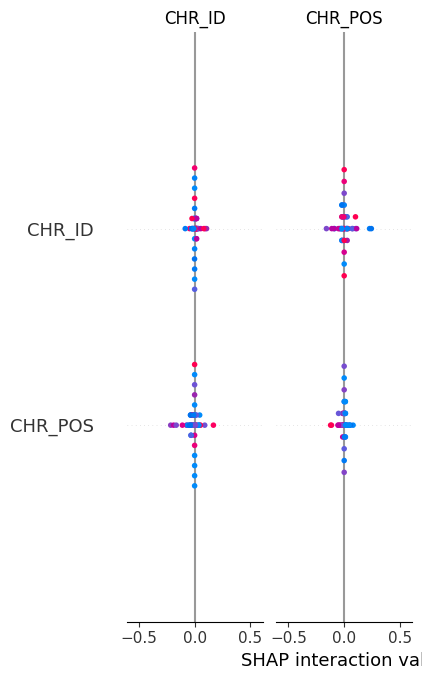

In [27]:
shap.summary_plot(
    shap_values_opt,
    X_test[:50],
    feature_names=features
)

In [28]:
results = pd.DataFrame({
    "Model": ["Optimized MLP"],
    "Accuracy": [accuracy_score(y_test, y_pred_opt)],
    "ROC_AUC": [roc_auc_score(y_test, y_prob_opt)]
})

results.to_csv(
    r"C:\Users\Haarun\obesity_project\results\experiment_4_optimized_mlp_results.csv",
    index=False
)

print(results)

           Model  Accuracy   ROC_AUC
0  Optimized MLP  0.867314  0.866373


In [29]:
comparison_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM",
        "MLP",
        "XGBoost",
        "Optimized MLP"
    ],

    "Accuracy": [
        0.8317,
        0.9158,
        0.8478,
        0.9093,
        0.9029,
        accuracy_score(y_test, y_pred_opt)
    ],

    "ROC_AUC": [
        0.8774,
        0.9290,
        0.8995,
        0.8700,
        0.9309,
        roc_auc_score(y_test, y_prob_opt)
    ]
})

print(comparison_results)

                 Model  Accuracy   ROC_AUC
0  Logistic Regression  0.831700  0.877400
1        Random Forest  0.915800  0.929000
2                  SVM  0.847800  0.899500
3                  MLP  0.909300  0.870000
4              XGBoost  0.902900  0.930900
5        Optimized MLP  0.867314  0.866373


In [30]:
comparison_results.to_csv(
    r"C:\Users\Haarun\obesity_project\results\final_model_comparison.csv",
    index=False
)

print("Final comparison table saved.")

Final comparison table saved.
